<a href="https://colab.research.google.com/github/hdflorez/Entrega_2/blob/main/dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos | 190304018-1 | 2026-1** | **Entrega 2** |

**Integrantes del equipo:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Fase 1: Exploración de Base de datos** | **Dataset 3: Credit Card Fraud Detection** |

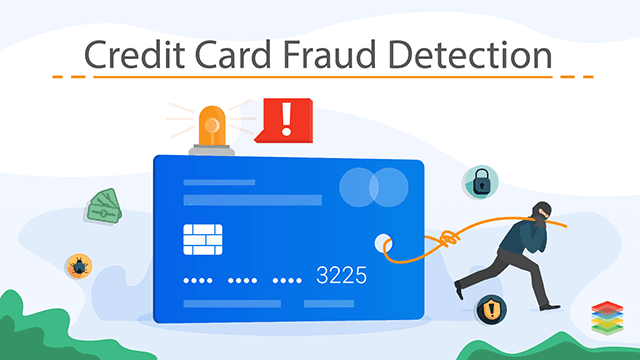

## **Generalidades del dataset**
La detección de transacciones fraudulentas es una necesidad crítica para las entidades emisoras de tarjetas de crédito, con el fin de proteger a los clientes de cargos no autorizados. Este dataset, disponible en Kaggle, reúne transacciones reales realizadas por titulares europeos durante septiembre de 2013, registradas a lo largo de dos días. De un total de 284 807 operaciones, 492 corresponden a fraudes, lo que representa el 0,172 % del total y evidencia un marcado desbalance entre clases. Al haber sido recopilada previamente por una entidad financiera y publicada para análisis, se clasifica como fuente secundaria, presentada en formato tabular (.csv).

Todas las variables son numéricas producto de una transformación PCA aplicada por razones de confidencialidad. Los componentes V1 a V28 corresponden a las variables transformadas, mientras que "Time" y "Amount" conservan su forma original: la primera indica los segundos transcurridos desde la primera transacción del conjunto, y la segunda refleja el monto de cada operación, siendo útil para enfoques de aprendizaje sensible al costo. La variable "Class" es la variable objetivo, con valor 1 para fraude y 0 para transacciones legítimas.

Su documentación es alta, aunque las variables se encuentran anonimizadas. Entre sus aplicaciones destacan la detección de fraude, el desarrollo de modelos de Machine Learning y el análisis de datos desbalanceados. Dado este desbalance, se recomienda evaluar el rendimiento mediante el área bajo la curva de precisión-exhaustividad (AUPRC), ya que métricas convencionales como la exactitud no resultan representativas en este tipo de escenarios. En términos generales, presenta alta completitud, relevancia y documentación, con una manejabilidad media, lo que lo convierte en un recurso muy adecuado para proyectos de clasificación y detección de fraude en contextos reales.

El dataset puede consutlarse en: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## **Características de dataset**
  * Registros: 284,807
  * Atributos: 31 (28 anonimizados + Time + Amount + Class)
  * Tamaño: ~150 MB
  * Problema: Clasificación binaria (fraude / no fraude)
  * Nota: Datos altamente desbalanceados

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [5]:
# Bloque 1: Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

ModuleNotFoundError: No module named 'pandas'

In [6]:
plt.style.use('default')
sns.set_palette("husl")

# Ubicación del dataset (archivo descargado de Kaggle)
path_dataset = path + "/creditcard.csv"

# Cargar el dataset
df = pd.read_csv(path_dataset)

# Visualización rápida
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

NameError: name 'plt' is not defined

In [12]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 284807, Columnas: 31


# **Fase 2: Análisis Exploratorio de Datos (EDA)**

In [14]:
#Paleta de colores
BLUE  = "#185FA5"
RED   = "#A32D2D"
GRAY  = "#73726C"

## **2.1 Revisión de valores faltantes**
    
    












In [15]:
# Conteo de nulos
valores_nulos = df.isnull().sum()

# Porcentaje de nulos
porcentaje_nulos = (valores_nulos / len(df)) * 100

# DataFrame
resumen_nulos = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': valores_nulos.values,
    'Porcentaje (%)': porcentaje_nulos.values
})

# Redondear porcentaje
resumen_nulos['Porcentaje (%)'] = resumen_nulos['Porcentaje (%)'].round(2)

# Mostrar tabla
resumen_nulos

,Columna,Valores Nulos,Porcentaje (%)
0,Time,0,0.0
1,V1,0,0.0
2,V2,0,0.0
3,V3,0,0.0
4,V4,0,0.0
5,V5,0,0.0
6,V6,0,0.0
7,V7,0,0.0
8,V8,0,0.0
9,V9,0,0.0


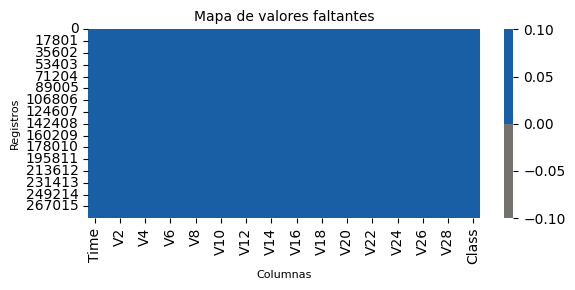

In [16]:
#Visualizacion de nulos
fig, ax = plt.subplots(figsize=(6, 3))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap=[GRAY, BLUE],
    ax=ax
)

ax.set_title("Mapa de valores faltantes", fontsize=10)
ax.set_xlabel("Columnas", fontsize=8)
ax.set_ylabel("Registros", fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
#Medidas y tomas de estrategia
resumen = []

for col in df.columns:

    total = len(df)
    nulos = df[col].isnull().sum()
    porcentaje_nulos = (nulos / total) * 100

    tipo = df[col].dtype

    # Medidas solo para numéricas
    if np.issubdtype(tipo, np.number):
        media = df[col].mean()
        mediana = df[col].median()
        moda = df[col].mode()[0] if not df[col].mode().empty else np.nan
        std = df[col].std()
        minimo = df[col].min()
        maximo = df[col].max()
    else:
        media = mediana = std = minimo = maximo = np.nan
        moda = df[col].mode()[0] if not df[col].mode().empty else np.nan

    # Estrategia automática
    if porcentaje_nulos == 0:
        estrategia = "Sin acción"
    elif porcentaje_nulos < 5:
        estrategia = "Imputación (media/mediana/moda)"
    elif porcentaje_nulos < 30:
        estrategia = "Imputación + indicador"
    else:
        estrategia = "Eliminar columna"

    resumen.append({
        "Columna": col,
        "Tipo": tipo,
        "Nulos": nulos,
        "% Nulos": porcentaje_nulos,
        "Media": media,
        "Mediana": mediana,
        "Moda": moda,
        "Std": std,
        "Minimo": minimo,
        "Maximo": maximo,
        "Estrategia Sugerida": estrategia
    })

resumen_df = pd.DataFrame(resumen)

tabla = resumen_df.style

tabla


,Columna,Tipo,Nulos,% Nulos,Media,Mediana,Moda,Std,Minimo,Maximo,Estrategia Sugerida
0,Time,float64,0,0.000000,94813.859575,84692.000000,163152.000000,47488.145955,0.000000,172792.000000,Sin acción
1,V1,float64,0,0.000000,0.000000,0.018109,1.245674,1.958696,-56.407510,2.454930,Sin acción
2,V2,float64,0,0.000000,0.000000,0.065486,-0.326668,1.651309,-72.715728,22.057729,Sin acción
3,V3,float64,0,0.000000,-0.000000,0.179846,-2.752041,1.516255,-48.325589,9.382558,Sin acción
4,V4,float64,0,0.000000,0.000000,-0.019847,-0.842316,1.415869,-5.683171,16.875344,Sin acción
5,V5,float64,0,0.000000,0.000000,-0.054336,-0.562777,1.380247,-113.743307,34.801666,Sin acción
6,V6,float64,0,0.000000,0.000000,-0.274187,-1.011073,1.332271,-26.160506,73.301626,Sin acción
7,V7,float64,0,0.000000,-0.000000,0.040103,-0.432126,1.237094,-43.557242,120.589494,Sin acción
8,V8,float64,0,0.000000,0.000000,0.022358,-0.160211,1.194353,-73.216718,20.007208,Sin acción
9,V9,float64,0,0.000000,-0.000000,-0.051429,0.170362,1.098632,-13.434066,15.594995,Sin acción


## **2.2 Detección de valores atípicos**

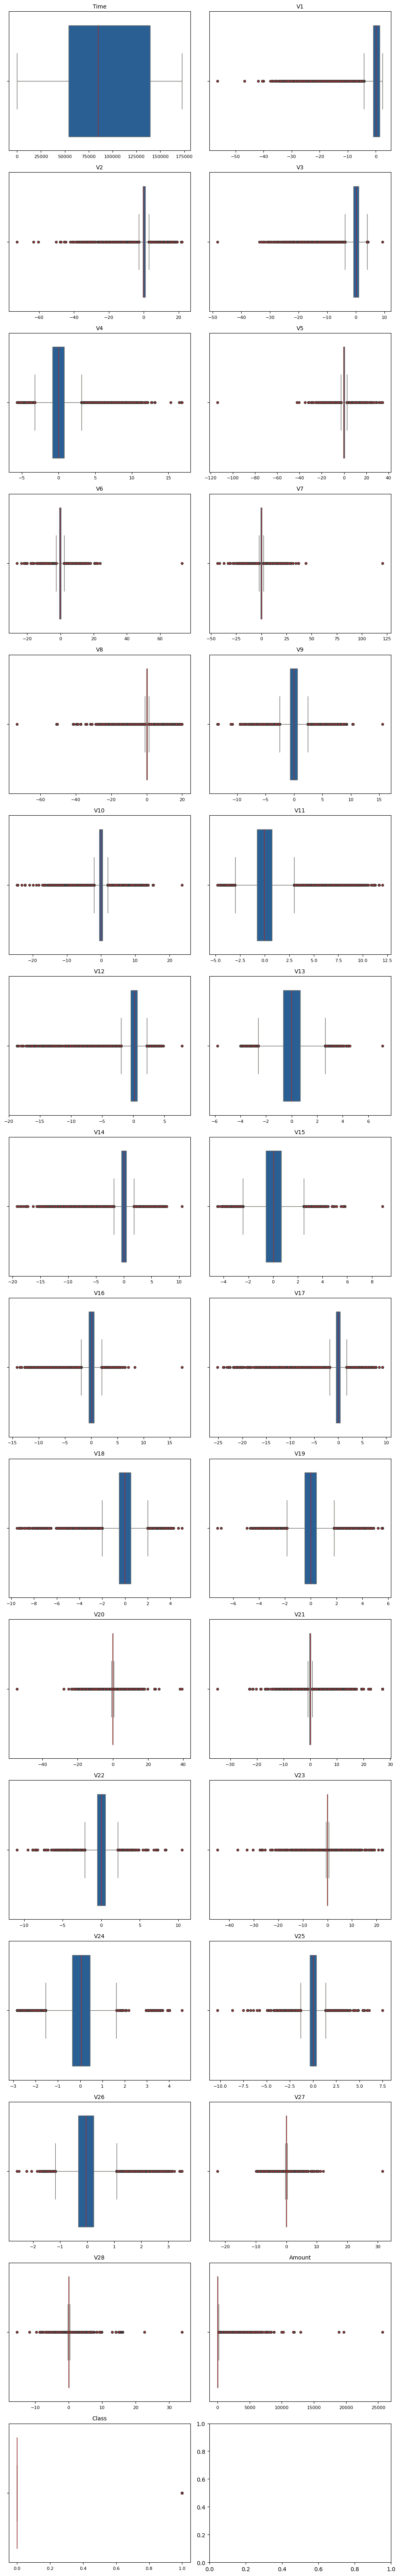

In [18]:
# Boxplots para variables numericas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Crear figura con varios subplots
n_cols = 2
n_rows = (len(columnas_numericas) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color=BLUE,
        flierprops=dict(marker='o', markerfacecolor=RED, markersize=4),  # outliers rojos
        boxprops=dict(edgecolor=GRAY),
        whiskerprops=dict(color=GRAY),
        capprops=dict(color=GRAY),
        medianprops=dict(color=RED)
    )

    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', labelsize=8)


plt.tight_layout()
plt.show()

In [19]:
# Detección de Outliers
# IQR
outliers_iqr = {}

for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    outliers_iqr[col] = len(outliers)


# Z-SCORE
z_scores = np.abs(zscore(df[columnas_numericas], nan_policy='omit'))
outliers_z = (z_scores > 3).sum(axis=0)

# TABLA
resumen_outliers = pd.DataFrame({
    "Columna": columnas_numericas,
    "Outliers (IQR)": [outliers_iqr[col] for col in columnas_numericas],
    "Outliers (Z-score)": outliers_z
})


# Mostrar tabla
resumen_outliers

,Columna,Outliers (IQR),Outliers (Z-score)
0,Time,0,0
1,V1,7062,3701
2,V2,13526,4318
3,V3,3363,1987
4,V4,11148,3094
5,V5,12295,2945
6,V6,22965,4652
7,V7,8948,3401
8,V8,24134,4221
9,V9,8283,2293


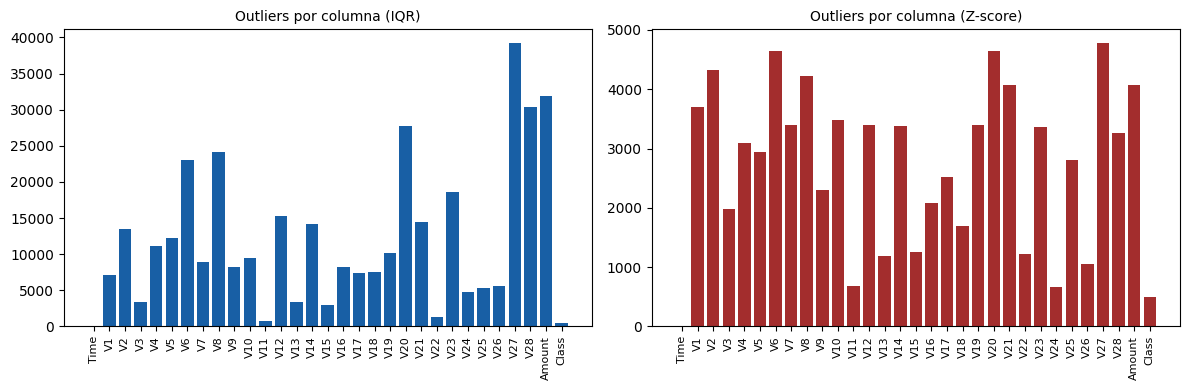

In [20]:
#Graficos IQR y # Z-SCORE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# IQR
axes[0].bar(resumen_outliers['Columna'], resumen_outliers['Outliers (IQR)'], color=BLUE)
axes[0].set_title("Outliers por columna (IQR)", fontsize=10)
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# Z-SCORE
axes[1].bar(resumen_outliers['Columna'], resumen_outliers['Outliers (Z-score)'], color=RED)
axes[1].set_title("Outliers por columna (Z-score)", fontsize=10)
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.show()


## **2.3 Análisis de distribuciones**


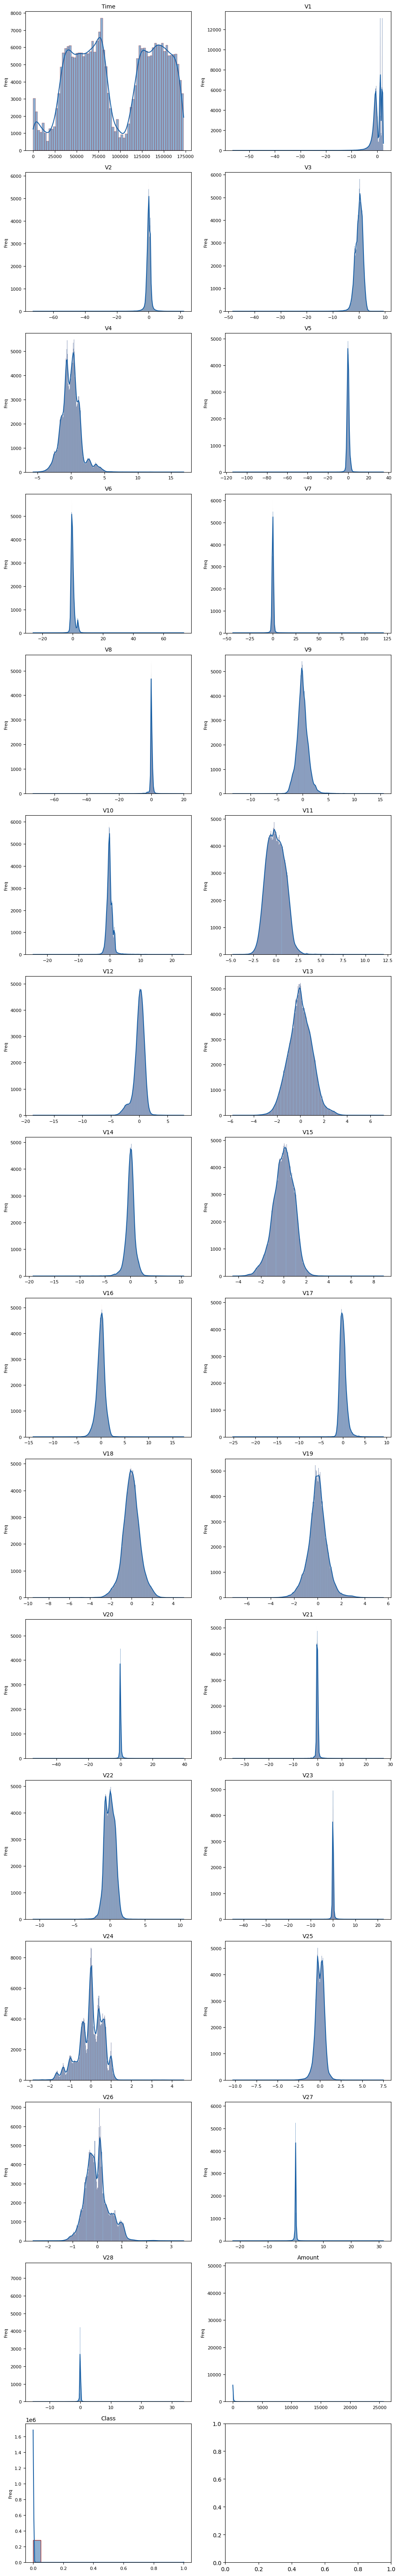

In [21]:
# Histograma + Densidad
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 2
n_rows = (len(columnas_numericas) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color=BLUE,
        edgecolor=RED,
        line_kws={'color': GRAY, 'linewidth': 1.5}
    )

    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Freq", fontsize=8)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [22]:
# Clasificar tipo de distribución
clasificacion = []

for col in columnas_numericas:
    skew = df[col].skew()

    if skew > 1:
        tipo = "Altamente sesgada a la derecha"
    elif skew > 0.5:
        tipo = "Moderadamente sesgada a la derecha"
    elif skew < -1:
        tipo = "Altamente sesgada a la izquierda"
    elif skew < -0.5:
        tipo = "Moderadamente sesgada a la izquierda"
    else:
        tipo = "Aproximadamente normal"

    clasificacion.append({
        "Columna": col,
        "Skewness": round(skew, 3),
        "Tipo de Distribución": tipo
    })

# Crear DataFrame
tabla_distribucion = pd.DataFrame(clasificacion)

# Ordenar por skewness (opcional)
tabla_distribucion = tabla_distribucion.sort_values(by="Skewness", ascending=False)

# Mostrar tabla
tabla_distribucion

,Columna,Skewness,Tipo de Distribución
30,Class,23.998,Altamente sesgada a la derecha
29,Amount,16.978,Altamente sesgada a la derecha
28,V28,11.192,Altamente sesgada a la derecha
21,V21,3.593,Altamente sesgada a la derecha
7,V7,2.554,Altamente sesgada a la derecha
6,V6,1.827,Altamente sesgada a la derecha
10,V10,1.187,Altamente sesgada a la derecha
4,V4,0.676,Moderadamente sesgada a la derecha
26,V26,0.577,Moderadamente sesgada a la derecha
9,V9,0.555,Moderadamente sesgada a la derecha


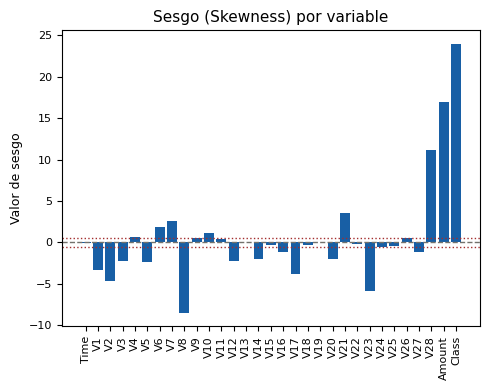

In [23]:
# Calcular sesgo
sesgo = df[columnas_numericas].skew()

plt.figure(figsize=(5,4))

# Barras
plt.bar(sesgo.index, sesgo.values, color=BLUE)

# Línea en 0 (referencia)
plt.axhline(0, color=GRAY, linestyle='--', linewidth=1)

# Líneas de umbral (opcional pero pro)
plt.axhline(0.5, color=RED, linestyle=':', linewidth=1)
plt.axhline(-0.5, color=RED, linestyle=':', linewidth=1)

# Estética
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title("Sesgo (Skewness) por variable", fontsize=11)
plt.ylabel("Valor de sesgo", fontsize=9)

plt.tight_layout()
plt.show()

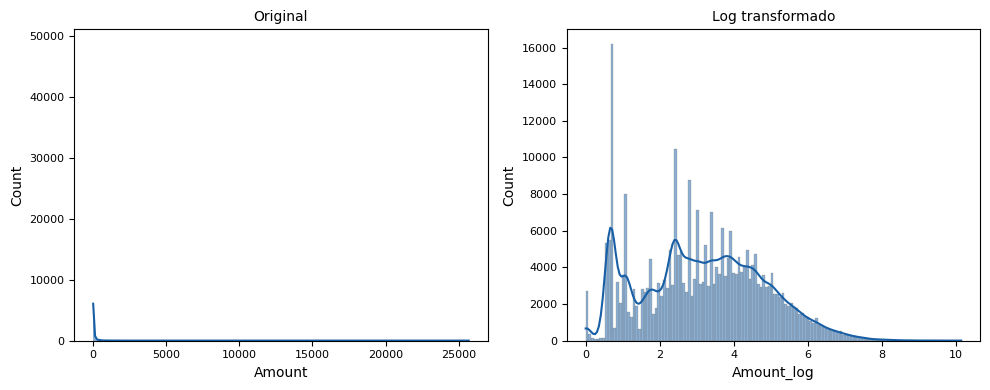

In [24]:
# Transformación logarítmica
df['Amount_log'] = np.log1p(df['Amount'])

fig, axes = plt.subplots(1, 2, figsize=(10,4))

#ORIGINAL
sns.histplot(
    df['Amount'],
    kde=True,
    ax=axes[0],
    color=BLUE,
    edgecolor=GRAY,
    line_kws={'color': RED}
)
axes[0].set_title("Original", fontsize=10)
axes[0].tick_params(labelsize=8)

# TRANSFORMADO
sns.histplot(
    df['Amount_log'],
    kde=True,
    ax=axes[1],
    color=BLUE,
    edgecolor=GRAY,
    line_kws={'color': RED}
)
axes[1].set_title("Log transformado", fontsize=10)
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

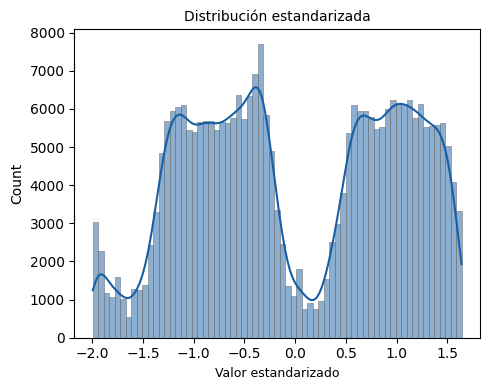

In [25]:
#Estandarización
scaler = StandardScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])
df[columnas_numericas]

plt.figure(figsize=(5,4))

sns.histplot(
    df[columnas_numericas[0]],  # prueba con una columna
    kde=True,
    color=BLUE,
    edgecolor=GRAY,
    line_kws={'color': RED}
)

plt.title("Distribución estandarizada", fontsize=10)
plt.xlabel("Valor estandarizado", fontsize=9)

plt.tight_layout()
plt.show()

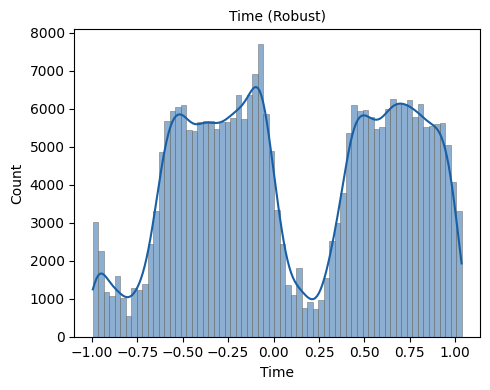

In [28]:
#Escalado robusto
scaler = RobustScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])
df[columnas_numericas]

plt.figure(figsize=(5,4))

sns.histplot(
    df[columnas_numericas[0]],
    kde=True,
    color=BLUE,
    edgecolor=GRAY,
    line_kws={'color': RED}
)

plt.title(f"{columnas_numericas[0]} (Robust)", fontsize=10)
plt.tight_layout()
plt.show()


##  **2.4 Análisis univariado**


In [3]:
print("\n--- ANÁLISIS UNIVARIADO ---")

# Variables numéricas
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# Variable categórica (Class)
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Distribución de transacciones (0 = normal, 1 = fraude)")
plt.show()

print("\nDistribución porcentual de la variable Class:")
print(df["Class"].value_counts(normalize=True))


--- ANÁLISIS UNIVARIADO ---


NameError: name 'df' is not defined

##  **2.5 Analísis multivalorado**


In [2]:
print("\n--- ANÁLISIS MULTIVARIADO ---")

# Matriz de correlación
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Mapa de calor de correlaciones")
plt.show()

# Correlación con la variable objetivo
corr_target = corr["Class"].sort_values(ascending=False)
print("\nCorrelación con la variable objetivo (Class):")
print(corr_target)

# Selección de variables más relevantes
top_corr = corr_target[1:6].index
low_corr = corr_target[-5:].index
selected_cols = list(top_corr) + list(low_corr) + ["Class"]

print("\nVariables seleccionadas para análisis:")
print(selected_cols)

# Diagramas de dispersión (pairplot)
sns.pairplot(df[selected_cols], hue="Class")
plt.show()

# 🔧 TABLAS CRUZADAS (REQUISITO)
print("\nTabla cruzada de la variable Class:")
print(pd.crosstab(df["Class"], df["Class"]))


--- ANÁLISIS MULTIVARIADO ---


NameError: name 'df' is not defined

## **2.6 Relaciones entre variables**


In [ ]:
print("\n--- RELACIONES ENTRE VARIABLES ---")

# Boxplots (numérica vs categórica)
for col in selected_cols:
    if col != "Class":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="Class", y=col, data=df)
        plt.title(f"{col} vs Fraude")
        plt.show()

##**2.7 Construcción de hipótesis iniciales**
De acuerdo con el dataset de detección de fraude en las tarjetas de crédito, se plantean las siguientes hipótesis:

  * **Hipótesis 1: El monto de la transacción influye en la probabilidad de fraude.** Los fraudes podrían concentrarse en montos atípicos de transacciones. Por un lado, pueden observarse transacciones de bajo monto utilizadas como mecanismo de validación inicial de la tarjeta (a manera de testo o prueba), y por otro, operaciones de alto valor realizadas con el fin de maximizar el beneficio económico antes de que el fraude sea detectado.
  * **Hipótesis 2: El fraude tiene patrones temporales.** Las transacciones fraudulentas a las tarjetas de crédito podrían darse en horas específicas, como en la madrugada, momento en el que la supervisión humana es menor a horarios habituales durante el día.
  * **Hipótesis 3: Los outliers en Amount están más asociados a transacciones legítimas que a fraudes.** Los fraudes pequeños, en donde se testean las transacciones en las tarjetas de crédito, pordrían ser más frecuentes que los de monto muy alto.
  * **Hipótesis 4: Existe un efecto de ráfaga: las transacciones fraudulentas tienden a concentrarse en periodos cortos de tiempo.** A diferencia del comportamiento habitual de los usuarios, en donde las transacciones con sus tarjetas de crédito suelen distribuirse de manera más uniforme a lo largo del día, los eventos fraudulentos podrían presentarse de forma más frecuente y agrupada en intervalos reducidos, como minutos u horas. Este patrón es consistente con la conducta de un atacante que, tras obtener acceso a una tarjeta de crédito de manera exitosa, intenta realizar múltiples operaciones en el menor tiempo posible antes de que sea bloqueada, con el fin de sacar el mayor provecho para beneficio propio.
  * **Hipótesis 5: Las transacciones fraudulentas tienen menor variabilidad en el monto que las legítimas.** Si los fraudes tienden a utilizar montos típicos o estandarizados (como €1, €5 o €9.99) con el objetivo de pasar desapercibidos, se esperaría que la variabilidad de estos valores sea menor en comparación con la de las transacciones legítimas.

##**2.8 Visualizaciones clave**

In [ ]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Columna auxiliar de hora
df["Hour"] = (df["Time"] // 3600).astype(int) % 24

legit_df = df[df["Class"] == 0]
fraud_df = df[df["Class"] == 1]

print(f"Legítimas : {len(legit_df):,}")
print(f"Fraudes   : {len(fraud_df):,}  ({len(fraud_df)/len(df)*100:.4f}%)")

Legítimas : 284,315
Fraudes   : 0  (0.0000%)


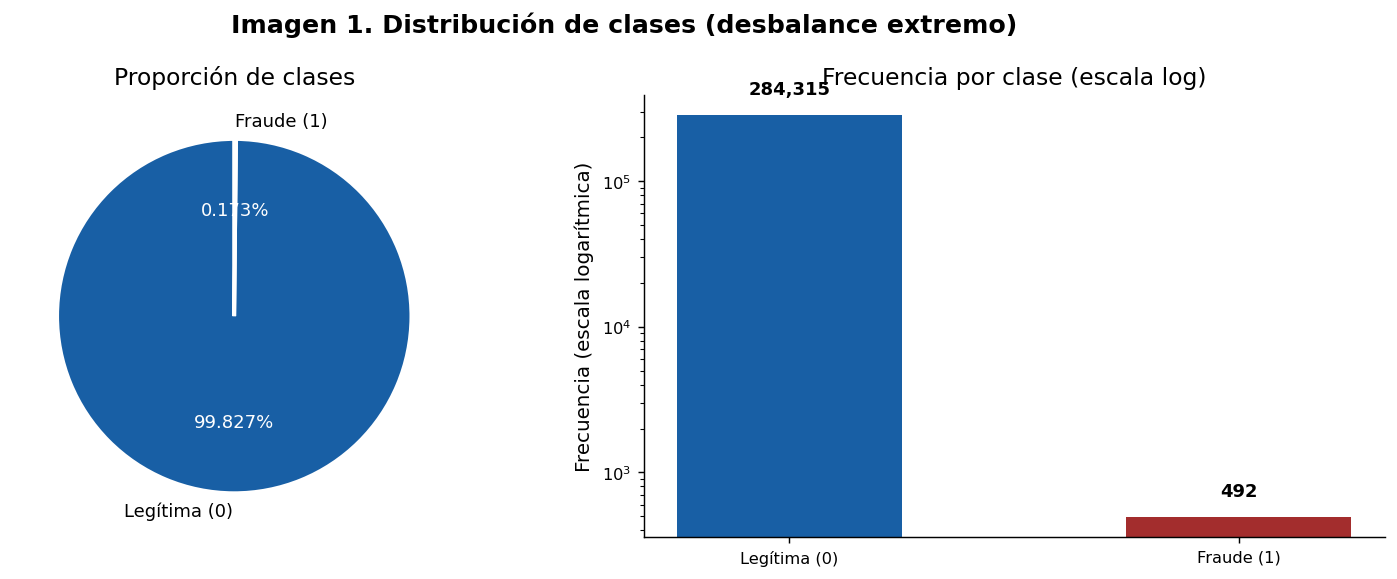

In [ ]:
#Visualización 1
counts = df["Class"].value_counts()
labels = ["Legítima (0)", "Fraude (1)"]
colors = [BLUE, RED]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Imagen 1. Distribución de clases (desbalance extremo)", fontsize=14, fontweight="bold")

wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, autopct="%1.3f%%", colors=colors,
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_color("white")
axes[0].set_title("Proporción de clases")

bars = axes[1].bar(labels, counts.values, color=colors, width=0.5, edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_ylabel("Frecuencia (escala logarítmica)")
axes[1].set_title("Frecuencia por clase (escala log)")
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val * 1.3,
                 f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("viz1_class_imbalance.png", bbox_inches="tight")
plt.show()

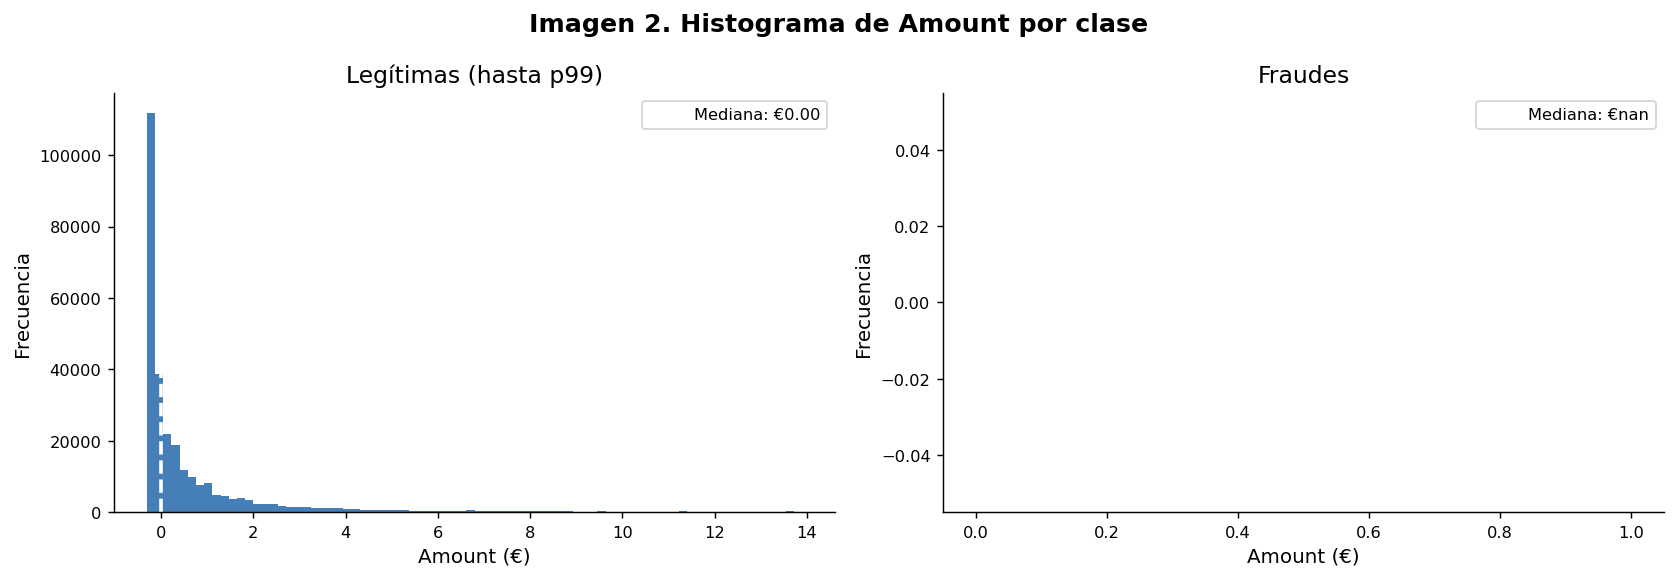

In [ ]:
#Visualización 2
legit_amt = legit_df["Amount"]
fraud_amt = fraud_df["Amount"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Imagen 2. Histograma de Amount por clase", fontsize=14, fontweight="bold")

cap = legit_amt.quantile(0.99)
axes[0].hist(legit_amt[legit_amt <= cap], bins=80, color=BLUE, alpha=0.8, edgecolor="none")
axes[0].axvline(legit_amt.median(), color="white", linewidth=2, linestyle="--",
                label=f"Mediana: €{legit_amt.median():.2f}")
axes[0].set_title("Legítimas (hasta p99)")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

axes[1].hist(fraud_amt, bins=40, color=RED, alpha=0.8, edgecolor="none")
axes[1].axvline(fraud_amt.median(), color="white", linewidth=2, linestyle="--",
                label=f"Mediana: €{fraud_amt.median():.2f}")
axes[1].set_title("Fraudes")
axes[1].set_xlabel("Amount (€)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("viz2_amount_histogram.png", bbox_inches="tight")
plt.show()

In [ ]:
#Visualización 3
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Imagen 3. Boxplots de Amount (Legítimas vs Fraudes)", fontsize=14, fontweight="bold")

cap99 = legit_amt.quantile(0.99)
bp = axes[0].boxplot(
    [legit_amt.clip(upper=cap99), fraud_amt],
    labels=["Legítima\n(cap p99)", "Fraude"],
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2.5},
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.5},
    widths=0.5,
)
bp["boxes"][0].set_facecolor(BLUE); bp["boxes"][0].set_alpha(0.75)
bp["boxes"][1].set_facecolor(RED);  bp["boxes"][1].set_alpha(0.75)
axes[0].set_ylabel("Amount (€)")
axes[0].set_title("Comparación directa")

stats_text = (
    f"Legítimas — Mediana: €{legit_amt.median():.2f} | "
    f"IQR: €{legit_amt.quantile(0.25):.2f}–€{legit_amt.quantile(0.75):.2f}\n"
    f"Fraudes   — Mediana: €{fraud_amt.median():.2f} | "
    f"IQR: €{fraud_amt.quantile(0.25):.2f}–€{fraud_amt.quantile(0.75):.2f}"
)
axes[0].text(0.02, 0.97, stats_text, transform=axes[0].transAxes,
             fontsize=8.5, va="top", ha="left",
             bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85})

vp = axes[1].violinplot(
    [legit_amt.clip(upper=500), fraud_amt],
    positions=[1, 2], showmedians=True, showextrema=False
)
for body, color in zip(vp["bodies"], [BLUE, RED]):
    body.set_facecolor(color)
    body.set_alpha(0.6)
vp["cmedians"].set_color("white")
vp["cmedians"].set_linewidth(2.5)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Legítima\n(cap €500)", "Fraude"])
axes[1].set_ylabel("Amount (€)")
axes[1].set_title("Violin plot")

plt.tight_layout()
plt.savefig("viz3_amount_boxplot.png", bbox_inches="tight")
plt.show()

In [ ]:
#Visualización 4
hourly      = df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)
hourly.columns = ["Legítima", "Fraude"]
hourly_norm = hourly.div(hourly.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
fig.suptitle("Imagen 4. Patrón temporal por hora del día", fontsize=14, fontweight="bold")

axes[0].fill_between(hourly.index, hourly["Legítima"], alpha=0.5, color=BLUE)
axes[0].plot(hourly.index, hourly["Legítima"], color=BLUE, linewidth=1.8, label="Legítimas")
ax_twin = axes[0].twinx()
ax_twin.fill_between(hourly.index, hourly["Fraude"], alpha=0.45, color=RED)
ax_twin.plot(hourly.index, hourly["Fraude"], color=RED, linewidth=1.8, label="Fraudes")
axes[0].set_ylabel("Legítimas (n)", color=BLUE)
ax_twin.set_ylabel("Fraudes (n)", color=RED)
axes[0].set_xticks(range(0, 24))
axes[0].set_xlabel("Hora del día")
axes[0].set_title("Frecuencias absolutas")
handles = [plt.Line2D([0],[0], color=BLUE, lw=2, label="Legítimas"),
           plt.Line2D([0],[0], color=RED,  lw=2, label="Fraudes")]
axes[0].legend(handles=handles, loc="upper left", fontsize=9)

axes[1].plot(hourly_norm.index, hourly_norm["Legítima"], color=BLUE, linewidth=2,
             marker="o", markersize=4, label="Legítimas (% de su clase)")
axes[1].plot(hourly_norm.index, hourly_norm["Fraude"],   color=RED,  linewidth=2,
             marker="s", markersize=4, linestyle="--", label="Fraudes (% de su clase)")
axes[1].fill_between(hourly_norm.index, hourly_norm["Legítima"], alpha=0.1, color=BLUE)
axes[1].fill_between(hourly_norm.index, hourly_norm["Fraude"],   alpha=0.1, color=RED)
axes[1].axvspan(0, 6, alpha=0.07, color=RED)
axes[1].text(3, hourly_norm.max().max() * 0.88, "Zona\nnocturna",
             ha="center", fontsize=8, color=RED, alpha=0.9)
axes[1].set_xticks(range(0, 24))
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("% del total de su clase")
axes[1].set_title("Distribución relativa por hora (normalizada por clase)", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("viz4_temporal_pattern.png", bbox_inches="tight")
plt.show()

In [ ]:
#Visualización 5
top_vars = ["V14", "V17", "V12", "V10", "V4", "V11"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    "Imagen 5. Variables PCA con mayor poder discriminatorio\n(Legítimas vs Fraudes)",
    fontsize=13, fontweight="bold"
)
axes = axes.flatten()

for i, var in enumerate(top_vars):
    ax  = axes[i]
    lo  = df[var].quantile(0.005)
    hi  = df[var].quantile(0.995)

    ax.hist(legit_df[var].clip(lo, hi), bins=60, color=BLUE, alpha=0.55,
            density=True, label="Legítima", edgecolor="none")
    ax.hist(fraud_df[var].clip(lo, hi), bins=40, color=RED,  alpha=0.65,
            density=True, label="Fraude",   edgecolor="none")

    x_range = np.linspace(lo, hi, 300)
    kde_l   = gaussian_kde(legit_df[var].clip(lo, hi).sample(min(5000, len(legit_df)), random_state=42))
    kde_f   = gaussian_kde(fraud_df[var].clip(lo, hi))
    ax.plot(x_range, kde_l(x_range), color=BLUE, linewidth=2)
    ax.plot(x_range, kde_f(x_range), color=RED,  linewidth=2, linestyle="--")

    ax.axvline(legit_df[var].mean(), color=BLUE, linewidth=1.2, linestyle=":", alpha=0.9)
    ax.axvline(fraud_df[var].mean(), color=RED,  linewidth=1.2, linestyle=":", alpha=0.9)

    delta = abs(fraud_df[var].mean() - legit_df[var].mean())
    ax.set_title(f"{var}  |  Δ media = {delta:.2f}", fontsize=11)
    ax.set_xlabel(var)
    ax.set_ylabel("Densidad")
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("viz5_pca_histograms.png", bbox_inches="tight")
plt.show()

In [ ]:
#Visualización 6
corr_vars   = ["V1","V2","V3","V4","V10","V11","V12","V14","V16","V17","Amount","Time","Class"]
corr_matrix = df[corr_vars].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Imagen 6. Correlaciones en el dataset", fontsize=14, fontweight="bold")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0],
    cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, square=True, cbar_kws={"shrink": 0.7},
)
axes[0].set_title("Matriz de correlación (triángulo inferior)")
axes[0].tick_params(axis="x", rotation=45)

corr_class = corr_matrix["Class"].drop("Class").sort_values()
colors_bar = [RED if v < 0 else BLUE for v in corr_class.values]
axes[1].barh(corr_class.index, corr_class.values, color=colors_bar, edgecolor="none", height=0.6)
axes[1].axvline(0, color=GRAY, linewidth=0.8)
axes[1].set_xlabel("Correlación de Pearson con Class")
axes[1].set_title("Correlación individual con Class (variable objetivo)")
for idx, val in corr_class.items():
    axes[1].text(val + (0.004 if val >= 0 else -0.004),
                 list(corr_class.index).index(idx),
                 f"{val:.3f}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig("viz6_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [ ]:
#Visualización 7
fraud_sample = fraud_df.copy()
legit_sample = legit_df.sample(2000, random_state=42)
sample       = pd.concat([legit_sample, fraud_sample])

pairs = [("V14", "V17"), ("V14", "V12"), ("V4", "V11")]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Imagen 7. Diagramas de dispersión — Variables PCA por clase\n"
    "(2 000 legítimas + todos los fraudes)",
    fontsize=13, fontweight="bold"
)

for ax, (vx, vy) in zip(axes, pairs):
    ax.scatter(sample[sample["Class"]==0][vx], sample[sample["Class"]==0][vy],
               c=BLUE, alpha=0.2, s=8, label="Legítima", edgecolors="none")
    ax.scatter(sample[sample["Class"]==1][vx], sample[sample["Class"]==1][vy],
               c=RED,  alpha=0.7, s=20, label="Fraude",   edgecolors="none")
    ax.set_xlabel(vx)
    ax.set_ylabel(vy)
    ax.set_title(f"{vx} vs {vy}")

axes[0].legend(fontsize=9, markerscale=1.8)

plt.tight_layout()
plt.savefig("viz7_scatter_plots.png", bbox_inches="tight")
plt.show()

In [ ]:
#Visualización 8
top6 = ["V14", "V17", "V12", "V10", "V4", "V11"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    "Imagen 8. Boxplots de variables PCA por clase\n(con test Mann-Whitney U)",
    fontsize=13, fontweight="bold"
)
axes = axes.flatten()

for i, var in enumerate(top6):
    ax         = axes[i]
    data_l     = legit_df[var]
    data_f     = fraud_df[var]

    bp = ax.boxplot(
        [data_l, data_f],
        patch_artist=True,
        labels=["Legítima", "Fraude"],
        medianprops={"color": "white", "linewidth": 2.2},
        flierprops={"marker": "o", "markersize": 1.5, "alpha": 0.15},
        whiskerprops={"linewidth": 1},
        capprops={"linewidth": 1.2},
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor(BLUE); bp["boxes"][0].set_alpha(0.72)
    bp["boxes"][1].set_facecolor(RED);  bp["boxes"][1].set_alpha(0.72)

    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_ylabel("Valor")

    _, pval = stats.mannwhitneyu(data_l, data_f, alternative="two-sided")
    sig     = "p < 0.001 ***" if pval < 0.001 else "p < 0.01 **" if pval < 0.01 else f"p = {pval:.3f}"
    ax.text(0.97, 0.97, sig, transform=ax.transAxes,
            ha="right", va="top", fontsize=8.5,
            color=RED if pval < 0.05 else GRAY)

plt.tight_layout()
plt.savefig("viz8_pca_boxplots.png", bbox_inches="tight")
plt.show()

##**2.9 Insights principales**

  * **2.9.1 Patrones más relevantes**
      * Desbalance extremo como reto central, ya que el dataset analizado contiene 492 fraudes sobre 284,807 transacciones (0.172%), lo que introduce un sesgo significativo hacia la clase mayoritaria si no se gestiona explícitamente en el modelado.
      * Montos más bajos en transacciones fraudulentas. La mediana en fraudes (aproximadament €9.25) es considerablemente menor que en transacciones legítimas (aproximadamente €22), lo que respalda la hipótesis de uso de montos pequeños para validar tarjetas antes de operaciones mayores.
      * Durante la madrugada, el volumen de transacciones legítimas disminuye, mientras que los fraudes se mantienen relativamente constantes, incrementando su proporción en ese intervalo.
      * Baja correlación individual de Amount y Time. Ambas variables muestran correlaciones prácticamente nulas con la clase, lo que indica que su capacidad predictiva aislada es limitada, aunque podrían aportar valor en combinación con otras variables.
      * Alta relevancia de variables latentes (V17 y V14). Estas componentes presentan las correlaciones más fuertes con la variable objetivo (-0.327 y -0.302) y muestran una clara separación de los fraudes en el espacio transformado, lo que sugiere que capturan patrones subyacentes críticos.

  * **2.9.2 Problemas de calidad detectados**
      * Falta de interpretabilidad en variables transformadas. Aunque no se observan valores nulos, las variables V1-V28 provienen de una transformación PCA y carecen de un significado directo desde el negocio, lo que limita tanto su validación como la posibilidad de construir nuevas variables con sentido analítico.
      * Ausencia de información contextual del cliente. El dataset no incluye variables categóricas ni identificadores de usuario, lo que dificulta analizar comportamientos a nivel individual o detectar posibles patrones de recurrencia en el fraude.
      * Cobertura temporal limitada. El dataset abarca únicamente dos días, lo que dificulta identificar patrones estacionales o tendencias de mediano y largo plazo.

  * **2.9.3 Líneas de análisis para fases posteriores**
      * Uso de métricas adecuadas en donde se prioricen métricas como    Precision-Recall en lugar de accuracy, dada la naturaleza desbalanceada del problema.
      * Evaluar algoritmos basados en árboles  que suelen manejar mejor este tipo de datos.
      * Considerar técnicas de detección de anomalías como Isolation Forest o Autoencoders, aprovechando la rareza de los fraudes.
      * Optimización del umbral de decisión: Ajustar el punto de corte del modelo en función del costo relativo entre fraude no detectado y falsas alarmas, alineándolo con objetivos de negocio.